In [1]:
from intan_reader import Recording
import numpy as np

In [2]:
# Load all the recordings from the test_recordings folder (actually there is only one file there...)
# Set the filter parameters to keep signals between 1 and 100 Hz, and remove the common noise @ 50 Hz with the notch filter
rec = Recording.from_folder("test_recordings/", "PBFDO", notch_freq=50, highpass_cutoff=1, lowpass_cutoff=100)


In [3]:
#fig, axes = rec.plot_channels(show=True)


In [4]:
# I reviewed the artifact detection method, but it is still not working as intended :/
artifacts = rec.detect_artifacts(method="envelope", threshold_uv=500, window_samples=int(rec.sample_rate))


In [5]:
raw_peaks, filtered_peaks = rec.detect_spikes(threshold=3, max_z_score=2, max_amplitude_uv=1000)


In [6]:
# Detect noisy channels
noise_result = rec.detect_noisy_channels(dip_threshold=0.05)
noisy_channels = np.where(noise_result["is_noisy"])[0].tolist()
 


C:\Users\Leo\anaconda3\Lib\site-packages\diptest\consts.py:702: UserWarning: Sample size exceeds the maximum limit of 72000. Results may not be accurate with precomputed statistical values.
  warnings.warn(


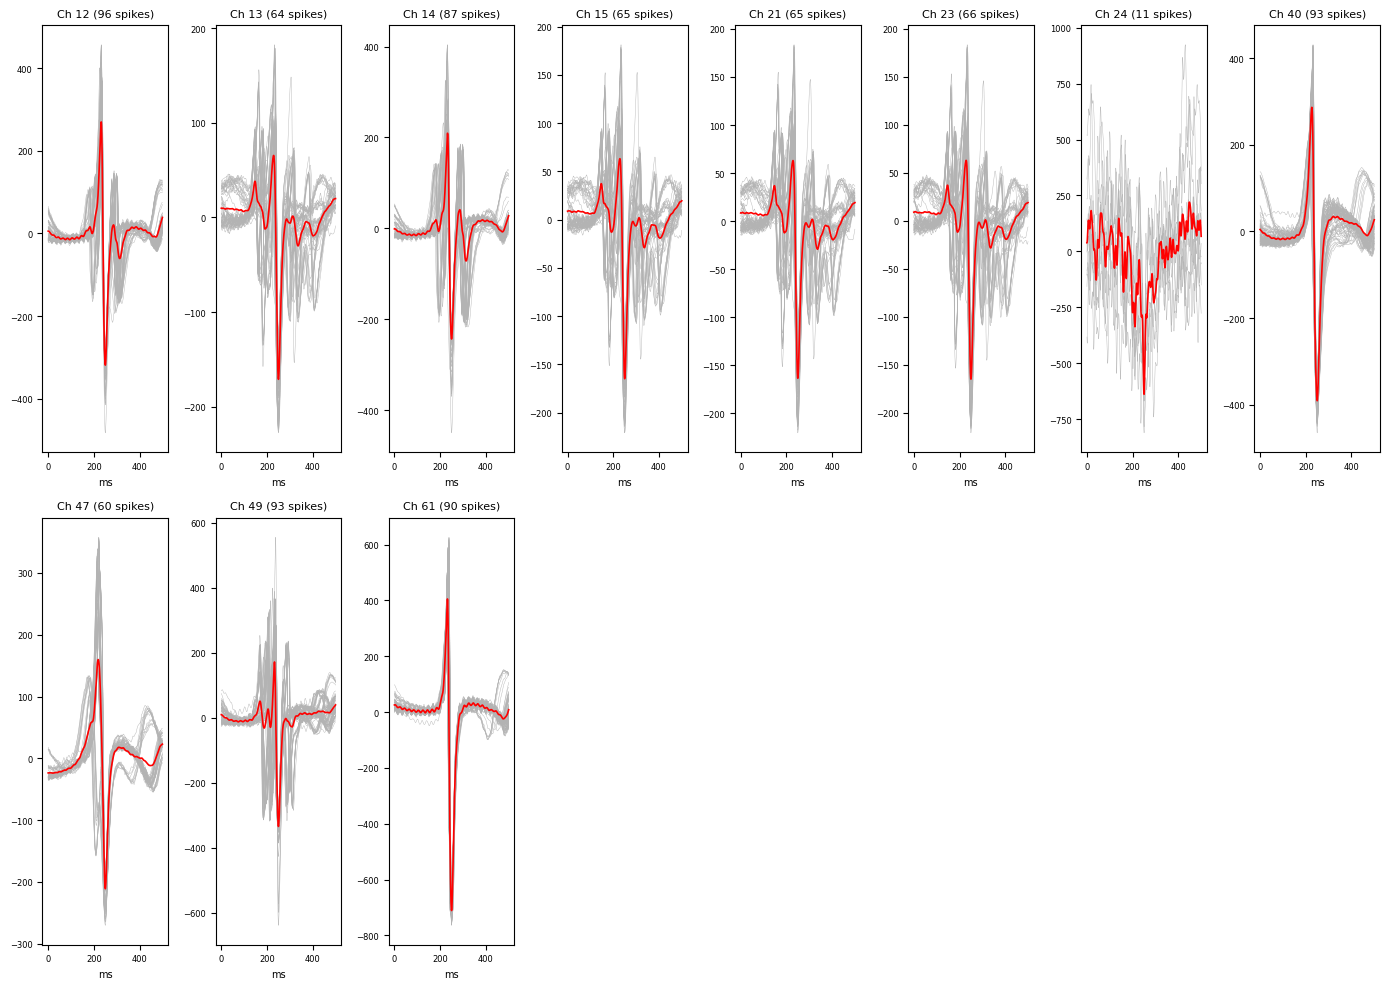

(<Figure size 1400x1000 with 16 Axes>,
 array([[<Axes: title={'center': 'Ch 12 (96 spikes)'}, xlabel='ms'>,
         <Axes: title={'center': 'Ch 13 (64 spikes)'}, xlabel='ms'>,
         <Axes: title={'center': 'Ch 14 (87 spikes)'}, xlabel='ms'>,
         <Axes: title={'center': 'Ch 15 (65 spikes)'}, xlabel='ms'>,
         <Axes: title={'center': 'Ch 21 (65 spikes)'}, xlabel='ms'>,
         <Axes: title={'center': 'Ch 23 (66 spikes)'}, xlabel='ms'>,
         <Axes: title={'center': 'Ch 24 (11 spikes)'}, xlabel='ms'>,
         <Axes: title={'center': 'Ch 40 (93 spikes)'}, xlabel='ms'>],
        [<Axes: title={'center': 'Ch 47 (60 spikes)'}, xlabel='ms'>,
         <Axes: title={'center': 'Ch 49 (93 spikes)'}, xlabel='ms'>,
         <Axes: title={'center': 'Ch 61 (90 spikes)'}, xlabel='ms'>,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [7]:
# Plot waveforms excluding noisy channels
rec.plot_waveforms(filtered_peaks, exclude_channels=noisy_channels)

In [8]:
# Compute spike statistics excluding noisy channels
spike_stats_df = rec.compute_spike_statistics(filtered_peaks, exclude_channels=noisy_channels)
print(spike_stats_df)

    channel  n_spikes   freq_hz     amp_min     amp_max    amp_mean  \
0        12        96  1.624119 -482.344744 -264.395418 -318.539194   
1        13        64  1.090751 -227.269871 -124.148475 -170.798049   
2        14        87  1.484762 -449.648035 -200.866258 -243.226265   
3        15        65  1.108066 -220.891428 -118.924297 -164.821261   
4        21        65  1.108064 -220.328606 -119.636529 -163.585593   
5        23        66  1.125380 -221.063964 -118.996179 -165.132880   
6        24        11  0.204020 -810.557988 -562.340043 -638.450342   
7        40        93  1.566047 -464.639732 -327.822699 -390.583923   
8        47        60  1.004600 -270.128063 -175.480336 -211.022310   
9        49        93  1.572033 -637.919735 -262.940140 -334.021054   
10       61        90  1.536809 -764.067291 -635.413191 -711.076382   

    amp_median    amp_std  isi_min_ms  isi_max_ms  isi_mean_ms  isi_median_ms  \
0  -317.047663  32.431563      535.55     1728.20   615.718421    

In [9]:
# Compute QT intervals excluding noisy channels
qt_df = rec.compute_qt_intervals(
    filtered_peaks,
    exclude_channels=noisy_channels,
    t_search_start_ms=25.0,   # start looking for T-end 50ms after Q
    t_search_end_ms=500.0,    # stop looking 500ms after Q
    smoothing_ms = 5
)
print(qt_df)

    channel  n_beats_deriv  qt_deriv_min_ms  qt_deriv_max_ms  \
0        12             80            50.85           249.75   
1        13             46            42.75           249.80   
2        14             84            51.25           248.25   
3        15             48            30.00           249.75   
4        21             44            56.05           249.00   
5        23             48            30.00           249.90   
6        24             10            77.35           248.85   
7        40             72            42.00           230.10   
8        47             40            49.40           249.80   
9        49             81            64.55           246.35   
10       61             73            69.35           248.60   

    qt_deriv_mean_ms  qt_deriv_median_ms  qt_deriv_std_ms  n_beats_baseline  \
0         106.170000              72.975        60.175913                73   
1         128.703261              87.125        69.912207                

<Axes: xlabel='wf_dev_max', ylabel='qt_avg_mean_ms'>

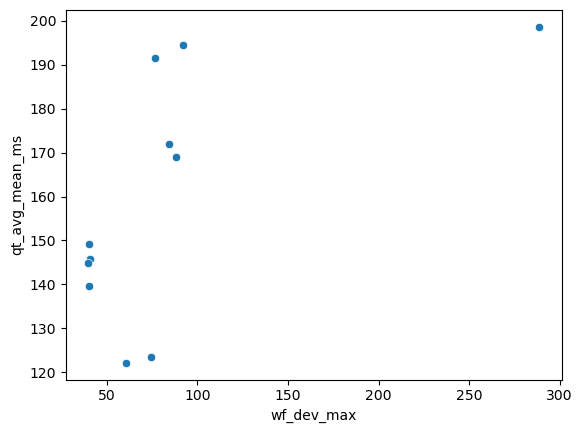

In [10]:
import seaborn as sns
sns.scatterplot(qt_df, y='qt_avg_mean_ms', x=spike_stats_df.wf_dev_max )

In [11]:
# Extract waveforms excluding noisy channels
waves, avg = rec.extract_waveforms(filtered_peaks, exclude_channels=noisy_channels)

In [23]:
avg

{12: array([ 5.7978465 ,  5.79147288,  5.78506859, ..., 38.60868698,
        38.70348473, 38.79820208]),
 13: array([ 9.8023465 ,  9.7960226 ,  9.78979836, ..., 19.94630136,
        19.94910819, 19.95199191]),
 14: array([-0.9630015 , -0.96603769, -0.96896387, ..., 27.60884137,
        27.6832052 , 27.75746474]),
 15: array([ 8.71872268,  8.72162306,  8.72466238, ..., 19.52717979,
        19.54221333, 19.55720596]),
 21: array([ 8.47058312,  8.46448977,  8.45857917, ..., 19.23448094,
        19.24137769, 19.24830171]),
 23: array([ 8.8507591 ,  8.85357992,  8.85653807, ..., 18.82253482,
        18.83476735, 18.84710731]),
 24: array([38.50441437, 38.47343137, 38.46175015, ..., 69.78723537,
        68.65294864, 67.52851219]),
 40: array([ 4.4937331 ,  4.46861499,  4.44336951, ..., 26.85306909,
        26.92386044, 26.99442635]),
 47: array([-23.59954745, -23.60322536, -23.60672115, ...,  22.96727844,
         22.97477405,  22.98215118]),
 49: array([ 9.70898671,  9.70262708,  9.69604068

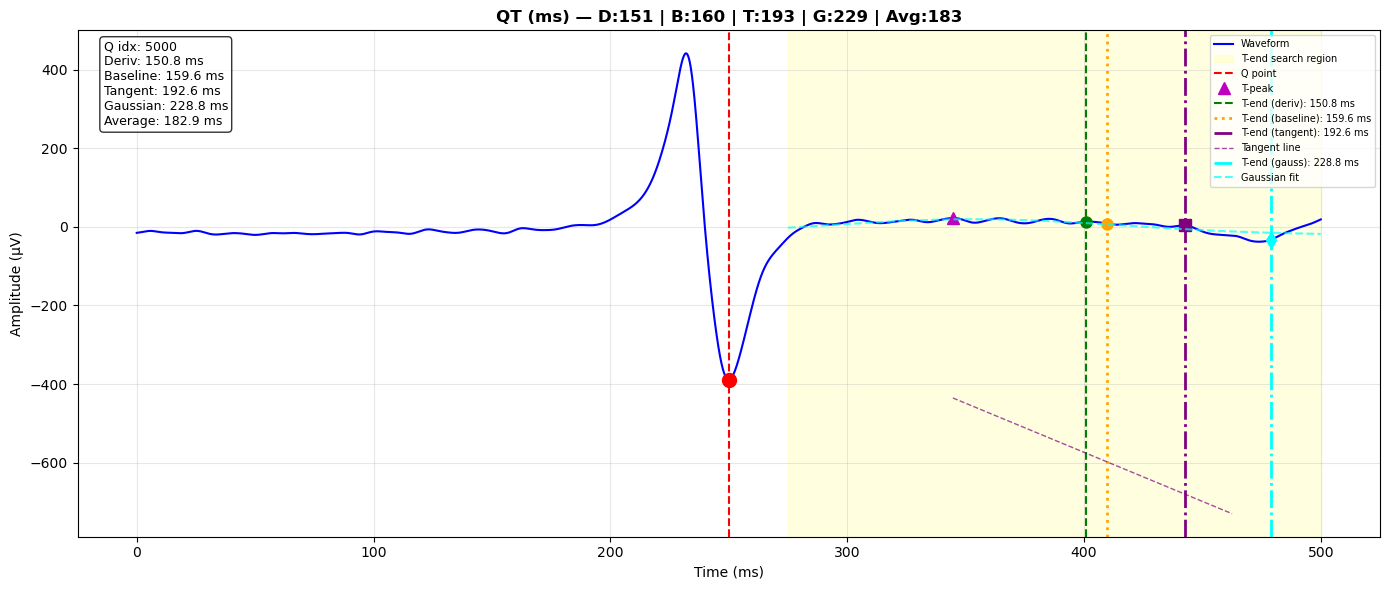

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'QT (ms) — D:151 | B:160 | T:193 | G:229 | Avg:183'}, xlabel='Time (ms)', ylabel='Amplitude (µV)'>)

In [12]:
from intan_reader.processing import plot_qt_detection

# Plot QT detection
plot_qt_detection(waves[12][15], rec.sample_rate,
                  t_search_start_ms=25.0,   # start looking for T-end 50ms after Q
                  t_search_end_ms=500.0,    # stop looking 500ms after Q
                  smoothing_ms = 5)

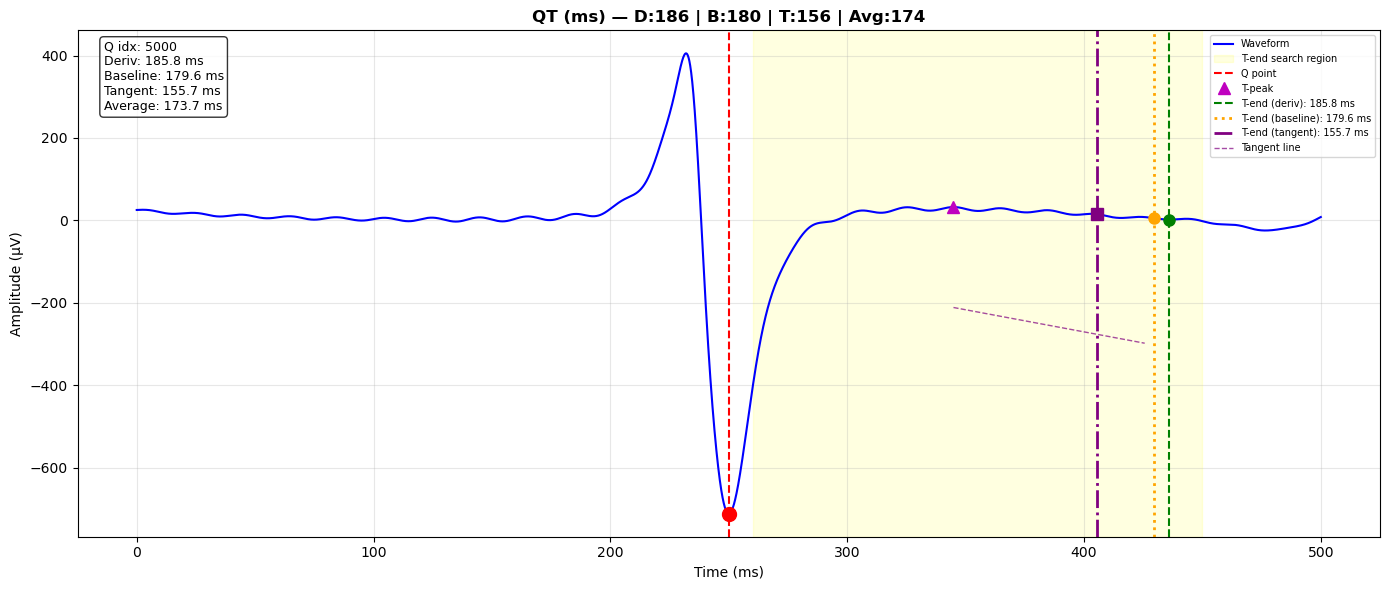

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'QT (ms) — D:186 | B:180 | T:156 | Avg:174'}, xlabel='Time (ms)', ylabel='Amplitude (µV)'>)

In [33]:
from intan_reader.processing import plot_qt_detection

# Plot QT detection
plot_qt_detection(avg[61], rec.sample_rate,
                  t_search_start_ms=10.0,   # start looking for T-end 50ms after Q
                  t_search_end_ms=200.0,    # stop looking 500ms after Q
                  smoothing_ms = 10)

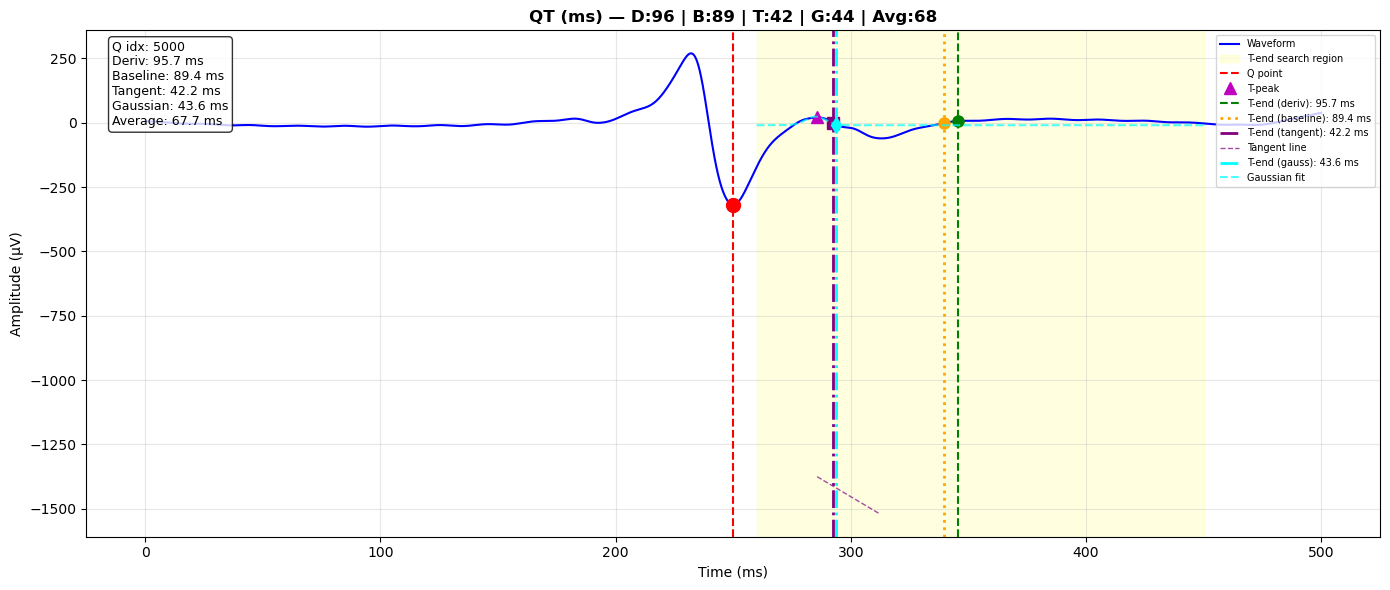

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'QT (ms) — D:96 | B:89 | T:42 | G:44 | Avg:68'}, xlabel='Time (ms)', ylabel='Amplitude (µV)'>)

In [34]:
# Plot QT detection
plot_qt_detection(avg[12], rec.sample_rate,
                  t_search_start_ms=10.0,   # start looking for T-end 50ms after Q
                  t_search_end_ms=200.0,    # stop looking 500ms after Q
                  smoothing_ms = 5)

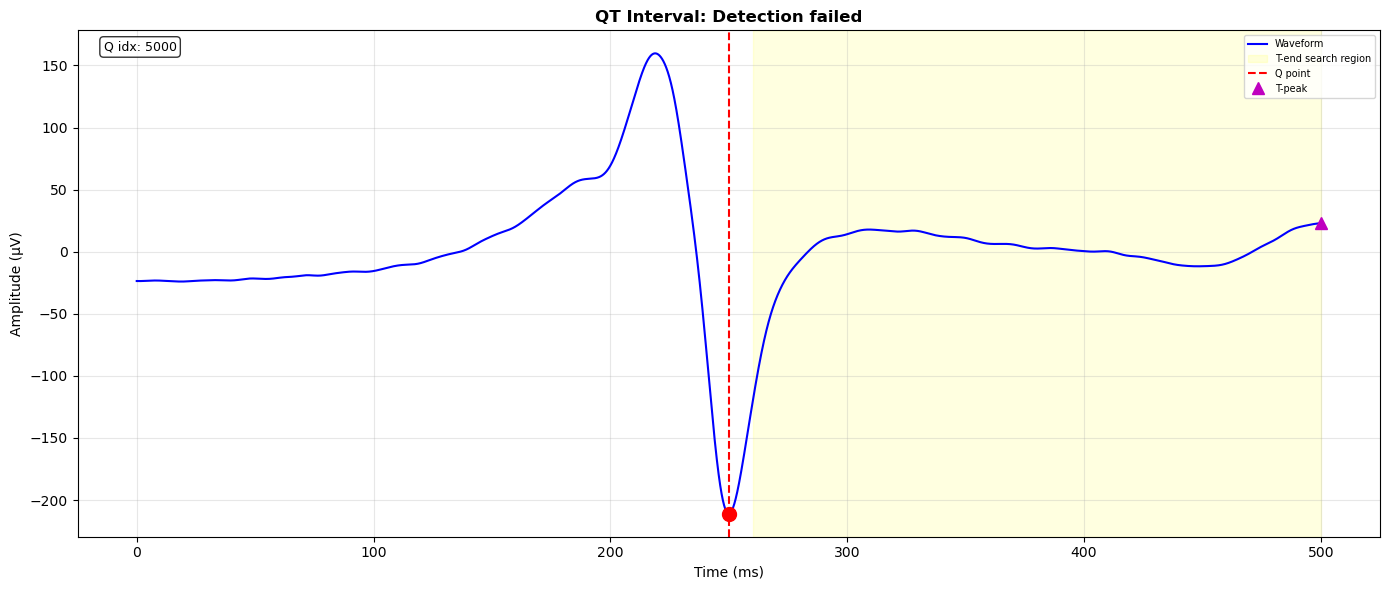

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'QT Interval: Detection failed'}, xlabel='Time (ms)', ylabel='Amplitude (µV)'>)

In [37]:
# Plot QT detection
plot_qt_detection(avg[47], rec.sample_rate,
                  t_search_start_ms=10.0,   # start looking for T-end 50ms after Q
                  t_search_end_ms=300.0,    # stop looking 500ms after Q
                  smoothing_ms = 5)